In [5]:
import jax
import jax.random as random
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import matplotlib.pyplot as plt
import optax.schedules as scheduler
%matplotlib inline

In [6]:
# install the pip package and import jVMC
# !pip install jVMC

import jVMC_exp
import jVMC_exp.operator.discrete as op

In [7]:
L = 10
g = -0.7

net = jVMC_exp.nets.CpxRBM(numHidden=8, bias=False)
n_steps = 300
n_samples = 2**12
n_chains = n_samples // 4
batch_size = n_samples

# Set up NQS and sampler 
psi = jVMC_exp.vqs.NQS(net, sampleShape=L, batchSize=batch_size, seed=123)
proposer = jVMC_exp.propose.SpinFlipZ2()
sampler = jVMC_exp.sampler.MCSampler(psi, proposer, key=123, numChains=n_chains, numSamples=n_samples, thermalizationSweeps=25)

In [8]:
def energy_single_p_mode(h_t, P):
    return np.sqrt(1 + h_t**2 - 2 * h_t * np.cos(P))

def ground_state_energy_per_site(h_t, N):
    Ps =  0.5 * np.arange(- (N - 1), N - 1 + 2, 2)
    Ps = Ps * 2 * np.pi / N
    energies_p_modes =  np.array([energy_single_p_mode(h_t, P) for P in Ps])
    
    return - 1 / N * np.sum(energies_p_modes)

exact_energy = ground_state_energy_per_site(g, L)
print(exact_energy)

-1.127222500154964


In [9]:
# Set up hamiltonian
hamiltonian = 0
for l in range(L):
    hamiltonian += -1 * op.SigmaZ(l) * op.SigmaZ((l + 1) % L) + g * op.SigmaX(l)

In [10]:
# Set up optimization
lr = scheduler.linear_schedule(1e-1, 1e-3, transition_steps=0.7*n_steps, transition_begin=0.3*n_steps)
stepper = jVMC_exp.stepper.Euler(lr)
loss_function = jVMC_exp.objective_function.Observable(hamiltonian)
solver = jVMC_exp.solver.PinvSNR(pinv_tol=1e-8)
# solver = jVMC_exp.solver.CG()
opt = jVMC_exp.optimizer.SR(sampler, psi, diagonalShift=1e-3, solver=solver)

/home/msolionas/code/Custom_jVMC/jVMC_exp/optimizer/base.py:252: UserWarning: Naming convention changed: 'diag_shift' now adds a constant term to the diagonal, while 'diag_scale' multiplies the diagonal entries. This is the opposite of the previous convention.
  warnings.warn(


In [11]:
out = opt.ground_state_search(n_steps, loss_function, stepper)

100%|██████████| 300/300 [01:22<00:00,  3.62it/s, E=-1.1267e+01+6.7411e-04j ± 2.6868e-03 (Var = 2.9568e-02)]

Recorded timings:
    - sampling: 54.933503s
    - compute objective function and gradient: 8.128597s
    - solve: 16.487768s


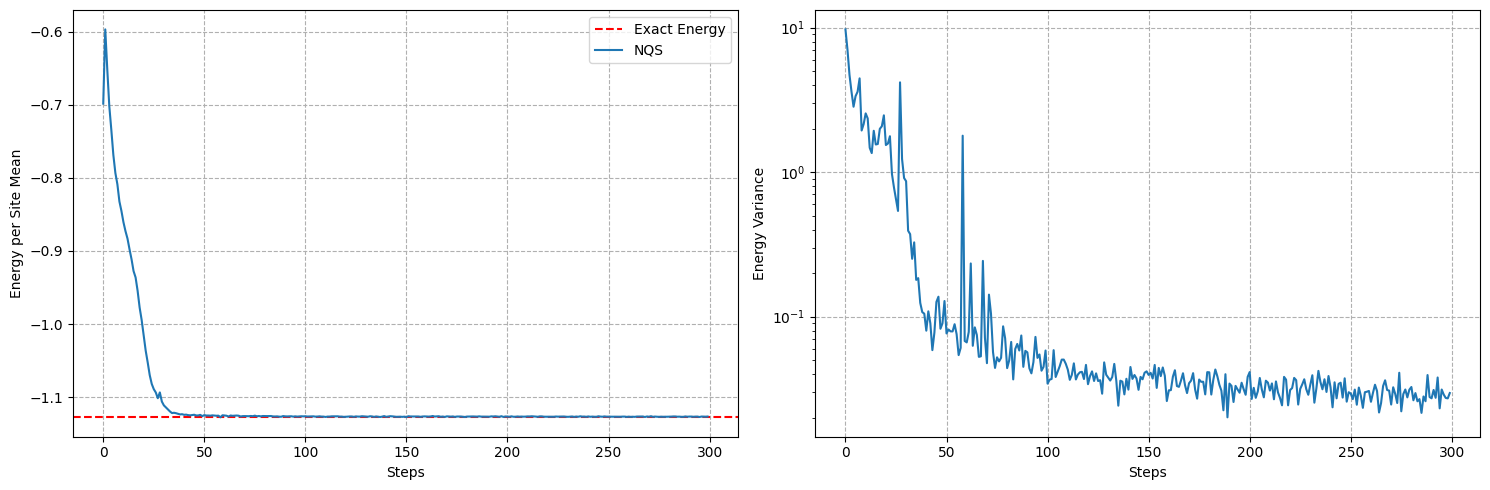

In [12]:
steps = out["times"]
energy_mean = np.array(out["energy"]["mean"]).real
energy_var = np.array(out["energy"]["variance"]).real

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.axhline(exact_energy, ls="--", color="red", label="Exact Energy")
plt.plot(steps, energy_mean / L, label="NQS")
plt.ylabel("Energy per Site Mean")
plt.xlabel("Steps")
plt.grid(ls="--")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(steps, energy_var)
plt.yscale("log")
plt.ylabel("Energy Variance")
plt.xlabel("Steps")
plt.grid(ls="--")

plt.tight_layout()